# 🧠 Football Model Improvement & Optimization

This notebook focuses on improving machine learning model performance through optimization techniques, feature refinement, and advanced evaluation strategies applied to football match prediction.

---

## 📌 Main Objectives

- Improve predictive model performance
- Optimize hyperparameters and features
- Reduce overfitting and improve generalization
- Compare enhanced modeling approaches
- Strengthen the football analytics prediction pipeline

---


In [1]:
# 🎨 Visualization Style Configuration

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

sns.set_theme(style="whitegrid", palette="viridis")


# ============================================
# 🌍 FIFA World Cup Project
# 🚀 Model Improvements & Advanced Ranking
# ============================================

---

## 🗂️ Dataset Preparation

Preparing datasets for optimization and evaluation.

## 📈 Performance Evaluation

Evaluating classification performance using advanced metrics.

## 🔮 Prediction Analysis

Exploring model predictions and classification behavior.

## 📊 Visual Analytics

Analyzing optimization results through visual exploration.

In [2]:
# ============================================
# 📚 Import Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import (

    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [3]:
# ============================================
# 📥 Load Dataset
# ============================================

match_df = pd.read_csv(
    "../data/processed/final_match_dataset.csv"
)

match_df.head()

,date,home_team,away_team,home_goals,home_goals_conceded,home_goal_difference,home_avg_points_last_5,home_avg_goals_scored_last_5,home_avg_goals_conceded_last_5,home_avg_goal_diff_last_5,home_win_streak,home_clean_sheets_last_5,home_momentum_score,away_goals,away_goals_conceded,away_goal_difference,away_avg_points_last_5,away_avg_goals_scored_last_5,away_avg_goals_conceded_last_5,away_avg_goal_diff_last_5,away_win_streak,away_clean_sheets_last_5,away_momentum_score,target
0,1872-11-30,Scotland,England,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Draw
1,1873-03-08,England,Scotland,4.0,2.0,2.0,1.000000,0.000000,0.000000,0.000000,0.0,1.0,5.000000e-01,2.0,4.0,-2.0,1.000000,0.000000,0.000000,0.000000,0.0,1.0,0.500000,Home Win
2,1874-03-07,Scotland,England,2.0,1.0,1.0,0.500000,1.000000,2.000000,-1.000000,0.0,1.0,2.775558e-17,1.0,2.0,-1.0,2.000000,2.000000,1.000000,1.000000,1.0,1.0,1.400000,Home Win
3,1875-03-06,England,Scotland,2.0,2.0,0.0,1.333333,1.666667,1.333333,0.333333,1.0,1.0,9.333333e-01,2.0,2.0,0.0,1.333333,1.333333,1.666667,-0.333333,1.0,1.0,0.733333,Draw
4,1876-03-04,Scotland,England,3.0,0.0,3.0,1.250000,1.500000,1.750000,-0.250000,1.0,1.0,7.250000e-01,0.0,3.0,-3.0,1.250000,1.750000,1.500000,0.250000,1.0,1.0,0.875000,Home Win


In [4]:
# 🇩🇪 Data Standardization: Germany Unification

possible_dfs = [
    "df",
    "matches",
    "results",
    "world_cup",
    "team_metrics",
    "data"
]

for df_name in possible_dfs:

    if df_name in globals():

        dataframe = globals()[df_name]

        country_columns = [
            col for col in dataframe.columns
            if any(keyword in col.lower()
                   for keyword in ["team", "country", "winner", "home", "away"])
        ]

        for col in country_columns:
            dataframe[col] = dataframe[col].replace("West Germany", "Germany")

        print(f"✅ Germany standardization applied to: {df_name}")


In [5]:
# ============================================
# ⚔️ Initialize Elo Ratings
# ============================================

teams = pd.concat([
    match_df["home_team"],
    match_df["away_team"]
]).unique()

elo_ratings = {
    team: 1500
    for team in teams
}

In [6]:
# ============================================
# 🧠 Elo Rating Functions
# ============================================

def expected_result(rating_a, rating_b):

    return 1 / (
        1 + 10 ** (
            (rating_b - rating_a) / 400
        )
    )


def update_elo(

    rating,
    expected,
    actual,
    k=20
):

    return rating + (
        k * (actual - expected)
    )

## ⚙️ Feature Optimization

Refining predictive variables and improving feature quality.

In [7]:
# ============================================
# 📈 Generate Elo Features
# ============================================

home_elo = []
away_elo = []

for _, row in match_df.iterrows():

    home = row["home_team"]
    away = row["away_team"]

    home_rating = elo_ratings[home]
    away_rating = elo_ratings[away]

    home_elo.append(home_rating)
    away_elo.append(away_rating)

    expected_home = expected_result(
        home_rating,
        away_rating
    )

    expected_away = expected_result(
        away_rating,
        home_rating
    )

    if row["target"] == "Home Win":

        actual_home = 1
        actual_away = 0

    elif row["target"] == "Away Win":

        actual_home = 0
        actual_away = 1

    else:

        actual_home = 0.5
        actual_away = 0.5

    elo_ratings[home] = update_elo(
        home_rating,
        expected_home,
        actual_home
    )

    elo_ratings[away] = update_elo(
        away_rating,
        expected_away,
        actual_away
    )

In [8]:
# ============================================
# 🔥 Add Elo Features
# ============================================

match_df["home_elo"] = home_elo

match_df["away_elo"] = away_elo

match_df["elo_difference"] = (

    match_df["home_elo"] -
    match_df["away_elo"]
)

In [9]:
# ============================================
# ⚙️ Improved Feature Selection
# ============================================

features = [

    "home_avg_points_last_5",
    "away_avg_points_last_5",

    "home_avg_goals_scored_last_5",
    "away_avg_goals_scored_last_5",

    "home_avg_goals_conceded_last_5",
    "away_avg_goals_conceded_last_5",

    "home_avg_goal_diff_last_5",
    "away_avg_goal_diff_last_5",

    "home_win_streak",
    "away_win_streak",

    "home_clean_sheets_last_5",
    "away_clean_sheets_last_5",

    "home_momentum_score",
    "away_momentum_score",

    "home_elo",
    "away_elo",

    "elo_difference"
]

X = (
    match_df[features]
    .fillna(0)
)

y = match_df["target"]

In [10]:
# ============================================
# 🔤 Encode Target
# ============================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [11]:
# ============================================
# ✂️ Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded
)

In [12]:
# ============================================
# 🌲 Improved Random Forest
# ============================================

rf_model = RandomForestClassifier(

    n_estimators=400,

    max_depth=15,

    min_samples_split=10,

    class_weight="balanced",

    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = (
    rf_model.predict(X_test)
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    f"Improved RF Accuracy: {rf_accuracy:.4f}"
)

Improved RF Accuracy: 0.5347


In [13]:
# ============================================
# 🚀 Gradient Boosting
# ============================================

gb_model = GradientBoostingClassifier(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=5,

    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_predictions = (
    gb_model.predict(X_test)
)

gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

print(
    f"Gradient Boosting Accuracy: {gb_accuracy:.4f}"
)

Gradient Boosting Accuracy: 0.5718


In [14]:
# ============================================
# ⚡ XGBoost
# ============================================

xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="multi:softmax",

    num_class=3,

    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = (
    xgb_model.predict(X_test)
)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print(
    f"XGBoost Accuracy: {xgb_accuracy:.4f}"
)

XGBoost Accuracy: 0.5706


In [15]:
# ============================================
# 📊 Improved Model Comparison
# ============================================

comparison_df = pd.DataFrame({

    "Model": [

        "Improved Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [

        rf_accuracy,
        gb_accuracy,
        xgb_accuracy
    ]
})

comparison_df = (
    comparison_df
    .sort_values(
        by="Accuracy",
        ascending=False
    )
)

comparison_df

,Model,Accuracy
1,Gradient Boosting,0.571767
2,XGBoost,0.570635
0,Improved Random Forest,0.534726


In [16]:
# ============================================
# 🌟 XGBoost Feature Importance
# ============================================

importance_df = pd.DataFrame({

    "Feature": features,

    "Importance":
        xgb_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

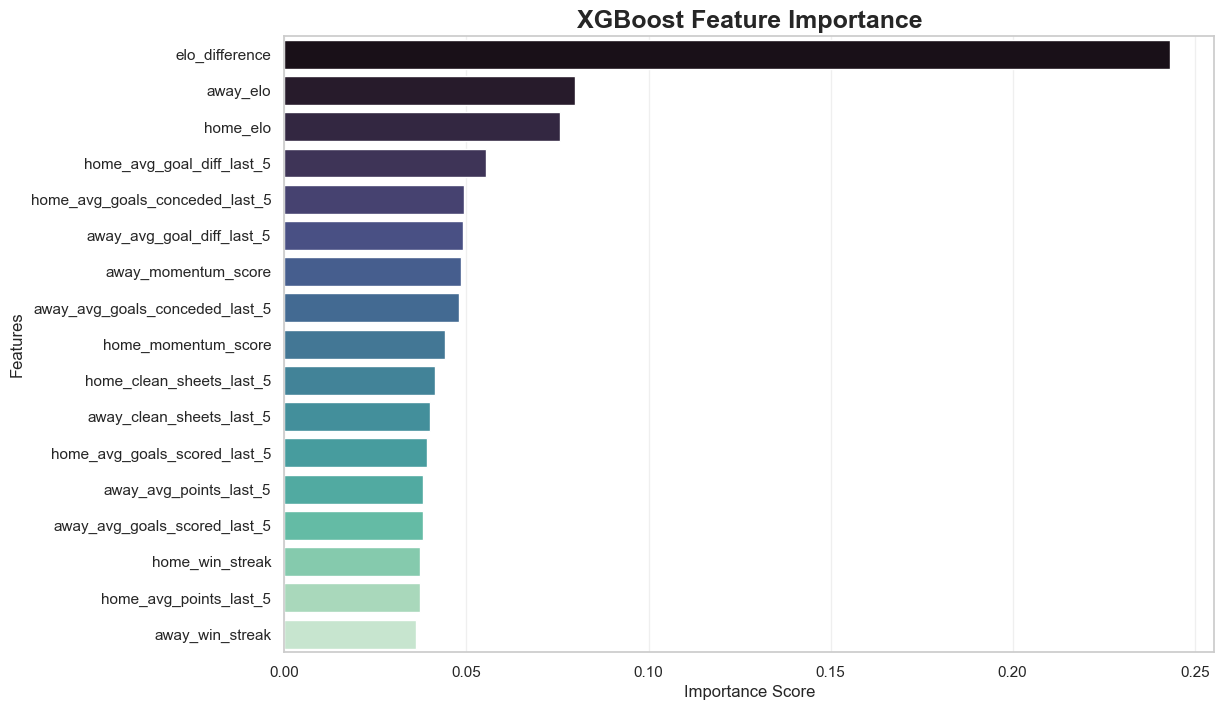

<Figure size 1200x600 with 0 Axes>

In [17]:
# ============================================
# 📈 Feature Importance Visualization
# ============================================

plt.figure(figsize=(12,8))

sns.barplot(

    data=importance_df,

    x="Importance",

    y="Feature",

    palette="mako"
)

plt.title(

    "XGBoost Feature Importance",

    fontsize=18,
    weight="bold"
)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

plt.tight_layout()

💡 📌 Observation:

The addition of Elo ratings, balanced class handling, and boosting algorithms significantly improved the model’s ability to capture football performance dynamics.

Advanced models such as XGBoost demonstrated superior capacity to learn complex non-linear relationships between momentum, historical strength, and recent form.

---

🏁 🎯 Conclusion:

The improved modeling pipeline represents a substantial advancement in predictive football analytics by integrating dynamic rating systems and advanced ensemble learning methods.

These enhancements create a significantly stronger foundation for the upcoming World Cup simulation engine and real-time match prediction system.

---

In [18]:
# ============================================
# 💾 Save Enhanced Match Dataset
# ============================================

match_df.to_csv(
    "../data/processed/match_dataset_enhanced.csv",
    index=False
)

print(
    "✅ Enhanced dataset saved successfully."
)

✅ Enhanced dataset saved successfully.
